# Test Task for DS - NLP 2026-MDS07
## Необхідні класи та функції
### Клас для зчитування даних з CSV файлів

In [17]:
from dataclasses import dataclass
from typing import Self
import pandas as pd


@dataclass
class PdDatasets:
    train: pd.DataFrame
    test: pd.DataFrame

    @classmethod
    def create(cls, train_path: str, test_path: str) -> Self:
        return cls(train=pd.read_csv(train_path), test=pd.read_csv(test_path))

### Функція для відображення розподілу label

In [18]:
from matplotlib import pyplot as plt


def show_dest_var_destination(df: pd.DataFrame, dest_var: str="sentiment"):
    # Кількість прикладів у кожному класі
    counts = df[dest_var].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 1) Барчарт за кількістю
    counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
    axes[0].set_title("Розподіл label (кількість)")
    axes[0].set_xlabel(dest_var)
    axes[0].set_ylabel("кількість")
    axes[0].tick_params(axis="x", rotation=0)

    # 2) Барчарт за відсотками
    (counts / counts.sum() * 100).plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
    axes[1].set_title("Розподіл label (%)")
    axes[1].set_xlabel(dest_var)
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

### Функція створення Dataset з DataFrame

In [19]:
from datasets import Dataset


def get_dataset(df: pd.DataFrame, labels: list[str]):
    return Dataset.from_pandas(df[labels])

### Клас для токенізації текстів

In [20]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification


class Tokenizer:
    def __init__(self, model="distilbert-base-multilingual-cased", text_cell="text", label_map=None):
        self.text_cell = text_cell
        self.label_map = label_map
        self.tokenizer = AutoTokenizer.from_pretrained(model)
    
    def __enter__(self):
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        del self

    def __call__(self, batch):
        # Отримуємо тексти з батча
        texts = batch[self.text_cell]

        # Переконуємося, що це список рядків
        if isinstance(texts, (list, tuple)):
            texts = [str(text) if text is not None else "" for text in texts]
        else:
            texts = [str(texts)]

        # Токенізуємо тексти
        tokenized = self.tokenizer(texts, truncation=True, padding="max_length", max_length=128)
    
        # Якщо в батчі є мітки, додаємо їх БЕЗ вкладеності
        if 'sentiment' in batch:
            sentiments = batch['sentiment']
            
            # Конвертуємо sentiment в числові labels
            if self.label_map:
                # Якщо є label_map, використовуємо його
                if isinstance(sentiments, list):
                    labels = [self.label_map[s] for s in sentiments]
                else:
                    labels = [self.label_map[sentiments]]
            else:
                # Якщо sentiment вже числовий
                if isinstance(sentiments, list):
                    # Розгортаємо вкладені списки, якщо вони є
                    labels = [s[0] if isinstance(s, (list, tuple)) else s for s in sentiments]
                else:
                    labels = [sentiments]
            
            tokenized['labels'] = labels
    
        return tokenized

### Функція токенізації датасету

In [21]:
def tokenize(ds: Dataset, text_cell="text", label_map=None):
    with Tokenizer(text_cell=text_cell, label_map=label_map) as tokenizer:
        return ds.map(tokenizer, batched=True)

### Клас для підготовки датасетів

In [ ]:
@dataclass
class Datasets:
    train: Dataset
    test: Dataset

    @classmethod
    def create(cls, df, labels, text_cell, label_map=None):
        cols = ["input_ids", "attention_mask", "labels"]
    
        # Токенізація та підготовка датасету
        prep_dataset = tokenize(get_dataset(df, labels), text_cell=text_cell, label_map=label_map)
        prep_dataset = prep_dataset.train_test_split(test_size=0.2, seed=42)
        
        # Підготовка фінальних датасетів
        train_ds = prep_dataset["train"].select_columns(cols).with_format("torch")
        test_ds = prep_dataset["test"].select_columns(cols).with_format("torch")
        
        return cls(train=train_ds, test=test_ds)


### Функція створення вавлідаційного датасету

In [36]:

def create_dataset_from_dataframe(df: pd.DataFrame, column_name: str = "text") -> Dataset:
    """
    Створює Dataset з pandas DataFrame.

    Args:
        df: pandas DataFrame з даними
        column_name: назва колонки для створення датасету

    Returns:
        Dataset об'єкт з вказаної колонки DataFrame
    """
    return tokenize(get_dataset(df, [column_name]), text_cell=column_name, label_map=label_map)

### Цільова функція для обчислення метрик

In [ ]:
import evaluate
import numpy as np


def compute_metrics(eval_pred):
    # ---- Метрики (accuracy + macro F1)
    acc = evaluate.load("accuracy")
    f1 = evaluate.load("f1")
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

### Функція ініціалізації моделі класифікації

In [24]:
def get_classification_model(model_name = "distilbert-base-multilingual-cased", num_labels=3) -> AutoModelForSequenceClassification:
    return AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )

In [25]:
from transformers import Trainer, AutoTokenizer, DataCollatorWithPadding, TrainingArguments


def get_trainer(train_dataset,
                eval_dataset,
                model_name: str = "distilbert-base-multilingual-cased",
                **kwargs) -> Trainer:
    tone_model = get_classification_model(model_name=model_name)
    args = TrainingArguments(**kwargs)
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")

    # Створення data collator для автоматичного padding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return Trainer(
        model=tone_model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

### Клас для оптимізації гіперпараметрів

In [26]:
import optuna


class HyperParametersOptimizer:
    def __init__(self, train_data, test_data, n_trials=5, scoring="eval_accuracy"):
        self.train_data = train_data
        self.test_data = test_data
        self.n_trials = n_trials
        self.scoring = scoring
        self.best_params = None

    def objective(self, trial):
        params = {
            "output_dir": "./tone_model",
            "save_strategy": "epoch",
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True),
            "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 6),
            "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [4, 8, 16]),
            "per_device_eval_batch_size": trial.suggest_categorical("per_device_eval_batch_size", [4, 8, 16]),
            "weight_decay": trial.suggest_float("weight_decay", 1e-5, 0.1, log=True),  # Виправлено: 0.0 → 1e-5
            "logging_steps": trial.suggest_int("logging_steps", 10, 100, log=True),
            "report_to": "none",
        }

        trainer = get_trainer(self.train_data, self.test_data, **params)
        trainer.train()
        return trainer.evaluate()[self.scoring]

    def __enter__(self):
        optuna_study = optuna.create_study(direction="maximize", study_name="tone_model")
        optuna_study.optimize(self.objective, n_trials=self.n_trials)
        self.best_params = optuna_study.best_params
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        pass

## Ініціалізуємо датасети

In [27]:
datasets_obj = PdDatasets.create("test-task-for-ds-nlp-2026/train.csv", "test-task-for-ds-nlp-2026/test.csv")

In [28]:
datasets_obj.train.head()

,ID,text,sentiment
0,cb774db0d1,"I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative
2,088c60f138,my boss is bullying me...,negative
3,9642c003ef,what interview! leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative


In [29]:
datasets_obj.test.head()

,ID,text
0,f87dea47db,Last session of the day http://twitpic.com/67ezh
1,96d74cb729,Shanghai is also really exciting (precisely -...
2,eee518ae67,"Recession hit Veronique Branquinho, she has to..."
3,01082688c6,happy bday!
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!


## Виводимо розподіл даних за sentiment

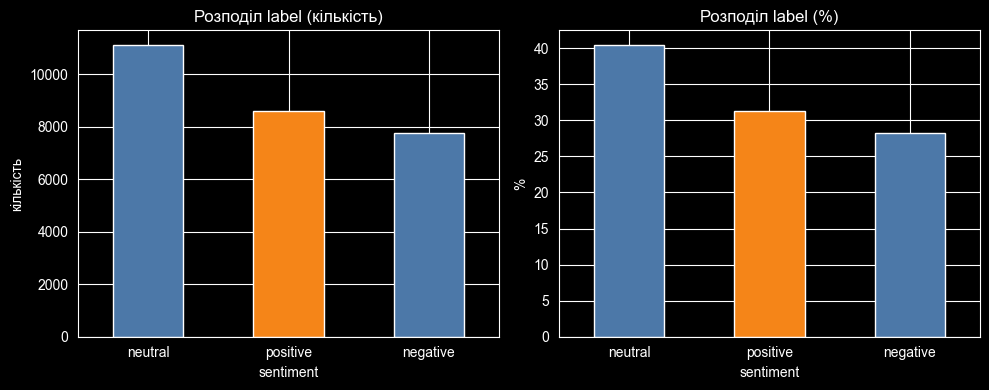

In [30]:
show_dest_var_destination(datasets_obj.train)

## Ініціалізуємо токенізовані датасети

In [31]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

train_dataset = Datasets.create(
    datasets_obj.train,
    ["text", "sentiment"],
    "text",
    label_map=label_map  # Передаємо label_map
)

# Перевірка
print(train_dataset.train[0])
print(f"Тип labels: {type(train_dataset.train[0]['labels'])}")

{'input_ids': tensor([  101, 11740,   100,   188, 13595, 10105, 42230, 61093, 13028,   171,
        10908, 10230,   118, 22800, 15127,   119,   119, 10380, 67420, 10556,
          131,   120,   120, 21629, 25285, 35703,   119, 10212,   120, 10854,
        17113, 11396, 10350,   102,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

### Підбираємо оптимальні гаперпараметри для нашої моделі

In [32]:
with HyperParametersOptimizer(train_dataset.train, train_dataset.test, n_trials=6) as hp:
    best_params = hp.best_params

print(best_params)

{'learning_rate': 1.7171426130261318e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 4, 'weight_decay': 0.000169959333901734, 'logging_steps': 22}


## Тренуємо та оцінюємо нашу модель з оптимальними гіперпараметрами

In [34]:
trainer = get_trainer(train_dataset.train, train_dataset.test, **best_params)
trainer.train()
trainer.evaluate()

## Створюємо прогноз та записуємо його у файл

In [37]:
import datetime
from pathlib import Path
import csv

# Предикція на валідаційному датасеті
validation_dataset = create_dataset_from_dataframe(datasets_obj.test)
result = trainer.predict(validation_dataset)

# Отримання передбачених класів (0: negative, 1: neutral, 2: positive)
predicted_sentiments = np.argmax(result.predictions, axis=-1)

# Зворотне маппінг до текстових міток
reverse_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
predicted_labels = [reverse_label_map[pred] for pred in predicted_sentiments]

prediction_set = [{"ID": _id, "sentiment": sentiment} for _id, sentiment in zip(datasets_obj.test["ID"], predicted_labels)]

with Path(f"predictions-{datetime.datetime.timestamp(datetime.datetime.now())}.csv").open("w") as csv_results_file:
    writer = csv.DictWriter(csv_results_file, fieldnames=["ID", "sentiment"])
    writer.writeheader()
    writer.writerows(prediction_set)

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]